# Per-parameter fit-closure test

One section per parameter. Each section trains **only that parameter** (the other 65 fixed at
truth) starting from an explicit, deliberately-wrong initial value, and plots its value vs epoch.

**How to use**
1. Run the four setup cells below once.
2. Go to a parameter's section and run its single cell: `closure("<name>", <init>)`.
3. To test a different starting point, **edit the number** and re-run that one cell — it retrains
   automatically (a cell re-uses its cached result only when the init / settings are unchanged).
   Pass `force=True` to always retrain.

Settings (events, steps, lr) live in the **config** cell. Outputs are saved under
`notebooks/per_param_closure/` (`configs/`, `histories/`, `figures/`).


In [2]:
import copy, json, subprocess, sys, time
from collections import Counter
from pathlib import Path

import numpy as np
import yaml
import matplotlib.pyplot as plt

# --- repo root (this notebook lives in <repo>/notebooks) ---
CWD = Path.cwd()
REPO = CWD.parent if CWD.name == "notebooks" else CWD
TRUTH_CFG = REPO / "src/parnassus/torch_delphes/param_configs/cms_target_default.yaml"
assert TRUTH_CFG.exists(), f"truth config not found: {TRUTH_CFG}"

# --- interpreter for the TRAINING subprocess (must have `parnassus` installed) ---
_venv_py = REPO / ".venv" / "bin" / "python"
PYTHON_CMD = [str(_venv_py)] if _venv_py.exists() else [sys.executable]
print("REPO       =", REPO)
print("PYTHON_CMD =", PYTHON_CMD)
_chk = subprocess.run(
    PYTHON_CMD + ["-c", "import parnassus.torch_delphes.tune_cms_fullsim"],
    cwd=str(REPO), capture_output=True, text=True,
)
assert _chk.returncode == 0, (
    "The training interpreter cannot import parnassus.\n"
    f"  PYTHON_CMD = {PYTHON_CMD}\n  stderr:\n{_chk.stderr}\n"
    "Fix: point PYTHON_CMD at the parnassus env python, or use ['uv','run','python']."
)
print("import check: OK")

REPO       = /global/u2/m/mukyu/MCGen/torch_delphes/parnassus
PYTHON_CMD = ['/global/u2/m/mukyu/MCGen/torch_delphes/parnassus/.venv/bin/python']
import check: OK


In [3]:
# ============================ settings (EDIT ME) ============================
ROOT_FILE = Path("/global/cfs/cdirs/m3246/Runze/MCGen/data/cms_pseudodata_100k.root")
N_EVENTS  = 5000          # events read from the ROOT file
N_STEPS   = 100            # Adam steps (epochs) per parameter (hard ceiling; was 120)
LR        = 1e-2           # global lr (effective per-param lr = LR * lr_scale)
SEED      = 0
OUT_DIR   = REPO / "notebooks" / "per_param_closure"
STREAM_STDOUT = False      # True -> print each training subprocess's full output live

# ---- closure-fit optimizer schedule (see per_param_closure diagnosis) -------
# The stochastic (resampled) loss makes ReduceLROnPlateau collapse the lr long
# before convergence and early stopping fire prematurely. For single-parameter
# closures we DISABLE the lr decay (constant lr), give early stopping a safe
# margin, and BOOST the resolution lr_scale 0.1 -> 1.0 so a_raw/b_raw converge in
# a few hundred constant-lr steps instead of ~1300.
LR_SCHEDULER_PATIENCE   = 0     # <= 0 -> disable lr decay (train at constant lr)
EARLY_STOPPING_PATIENCE = 10    # epochs of no val_loss improvement before stop
RESOLUTION_LR_SCALE     = 1.0   # per-closure override of the 0.1 default for a_raw/b_raw
# ===========================================================================

CFG_DIR  = OUT_DIR / "configs"
HIST_DIR = OUT_DIR / "histories"
FIG_DIR  = OUT_DIR / "figures"
for d in (CFG_DIR, HIST_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)
assert ROOT_FILE.exists(), f"ROOT file not found: {ROOT_FILE}"

with TRUTH_CFG.open() as f:
    truth_cfg = yaml.safe_load(f)
ALL_PARAMS = list(truth_cfg)
RESULTS = {}               # name -> last trajectory dict (filled by closure())
print(f"{len(ALL_PARAMS)} parameters; OUT_DIR = {OUT_DIR}")

66 parameters; OUT_DIR = /global/u2/m/mukyu/MCGen/torch_delphes/parnassus/notebooks/per_param_closure


In [4]:
# Transform family + default (deliberately-wrong) starting value, with load-safe guards.
def transform_kind(name):
    """Mirror parnassus...param_config.param_transform_kind (kept inline; no torch needed here)."""
    base = name.split("[", 1)[0]
    if base.endswith(".scale_raw") or base == "scale_raw":
        return "scale"
    if base.endswith((".eff_logits", "_logit")):
        return "logit"
    if base.endswith((".rate_raw", ".a_raw", ".b_raw")) or base.startswith(
        ("ECal.resolution_func", "HCal.resolution_func")):
        return "softplus"
    return "identity"

def family(name):
    k = transform_kind(name)
    if k == "softplus":
        return "rate" if ".rate_raw" in name else "resolution"
    return k

# Default-init magnitudes (used only when you call closure(name) with no init).
LOGIT_LO, LOGIT_HI = 0.2, 0.8
LOGIT_CLAMP        = (0.12, 0.88)
SCALE_LO, SCALE_HI = 0.78, 1.20
SCALE_CLAMP        = (0.72, 1.28)
SOFTPLUS_FACTOR    = 0.4

def perturbed_start(name, truth):
    k = transform_kind(name)
    if k == "scale":
        s = SCALE_LO if truth >= 1.0 else SCALE_HI
        return float(min(max(s, SCALE_CLAMP[0]), SCALE_CLAMP[1]))
    if k == "logit":
        s = LOGIT_LO if truth > 0.5 else LOGIT_HI
        return float(min(max(s, LOGIT_CLAMP[0]), LOGIT_CLAMP[1]))
    if k == "softplus":
        return float(max(SOFTPLUS_FACTOR * truth, 1e-6))
    return float(truth)

def validate_start(name, start):
    """'' if loadable, else the reason (mirrors param_config range guards)."""
    k = transform_kind(name)
    if k == "scale" and not (0.7 < start < 1.3):
        return f"scale start {start} not in open (0.7, 1.3)"
    if k == "logit" and not (0.1 < start < 0.9):
        return f"trainable logit start {start} not in open (0.1, 0.9)"
    if k == "softplus" and not (start > 0):
        return f"softplus start {start} not > 0"
    return ""

def slug(name):
    return name.replace(".", "_").replace("[", "_").replace("]", "")

In [5]:
# ---- the core function: train ONE parameter and plot its value vs epoch ----
def _train(name, init, cfg_path, hist_path, n_steps, n_events, lr, seed):
    cfg = copy.deepcopy(truth_cfg)                       # all 66 at truth, trainable: false
    cfg[name] = {**cfg[name], "value": float(init), "trainable": True}
    # Boost the resolution (a_raw/b_raw, ECal/HCal res) lr_scale for the closure:
    # the 0.1 default needs ~1300 constant-lr steps to converge a_raw (see diagnosis).
    if family(name) == "resolution":
        cfg[name]["lr_scale"] = RESOLUTION_LR_SCALE
    with cfg_path.open("w") as f:
        yaml.safe_dump(cfg, f, sort_keys=False, default_flow_style=False)
    tmp = hist_path.with_suffix(".json.partial")
    argv = PYTHON_CMD + [
        "-m", "parnassus.torch_delphes.tune_cms_fullsim",
        "--root-file", str(ROOT_FILE), "--n-events", str(n_events),
        "--n-steps", str(n_steps), "--lr", str(lr), "--seed", str(seed),
        "--param-config", str(cfg_path), "--history-path", str(tmp),
        "--intermediate-plot-dir", "",                   # disable per-epoch PDFs (speed)
        # Closure schedule: disable lr decay + safe early-stop margin (see cell 2).
        "--lr-scheduler-patience", str(LR_SCHEDULER_PATIENCE),
        "--early-stopping-patience", str(EARLY_STOPPING_PATIENCE),
    ]
    proc = subprocess.run(argv, cwd=str(REPO),
                          stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    if STREAM_STDOUT:
        print(proc.stdout)
    if proc.returncode != 0:
        # No gradient path to this param alone -> backward() raises. Real, informative result.
        if "does not require grad" in proc.stdout:
            return "no_grad"
        print("\n".join(proc.stdout.splitlines()[-20:]))
        return "FAILED"
    tmp.replace(hist_path)                               # promote only on success
    return "ok"

def _used_init(cfg_path, name):
    """The trainable init recorded in a saved config, or None."""
    if not cfg_path.exists():
        return None
    try:
        e = yaml.safe_load(cfg_path.read_text()).get(name)
        return float(e["value"]) if isinstance(e, dict) and e.get("trainable") else None
    except Exception:
        return None

def _meta_ok(hist_path, n_steps, n_events, lr):
    try:
        m = json.loads(hist_path.read_text())["metadata"]
        return (m.get("n_events") == n_events and m.get("n_steps") == n_steps
                and float(m.get("lr")) == float(lr))
    except Exception:
        return False

def _trajectory(hist_path, name, init):
    H = json.loads(hist_path.read_text())
    key = H["metadata"]["trainable_params"][0]
    ep  = sorted(H["history"].values(), key=lambda e: e["step"])     # sort by int step
    steps  = [e["step"] for e in ep]
    values = [e["parameters"][key] for e in ep]
    truth  = float(truth_cfg[name]["value"])
    start  = float(init)                                # epoch_0 is already post-1-epoch
    best   = H.get("best_result") or {}
    final  = float(best.get("parameters", {}).get(key, values[-1]))  # headline = best epoch
    last   = float(values[-1])
    gap0   = abs(start - truth)
    gap_closed = (1.0 - abs(final - truth) / gap0) if gap0 > 0 else float("nan")
    return dict(key=key, name=name, steps=steps, values=values, truth=truth, start=start,
                final=final, last=last, gap0=gap0, gap_closed=gap_closed,
                moved_correct=(final - start) * (truth - start) > 0, n_epochs=len(steps),
                val_loss_best=best.get("val_loss"), family=family(name),
                lr_scale=truth_cfg[name].get("lr_scale", 1.0),
                stopped_early=len(steps) < json.loads(hist_path.read_text())["metadata"]["n_steps"])

def plot_one(tr, ax=None, save=None):
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=(6.2, 3.8))
    xs = [-1] + list(tr["steps"])
    ys = [tr["start"]] + list(tr["values"])
    ax.plot(xs, ys, "-o", ms=4, lw=1.3, color="C0")
    ax.plot([-1], [tr["start"]], "*", ms=14, color="orange",
            label=f"start = {tr['start']:g}", zorder=5)
    ax.axhline(tr["truth"], ls="--", color="red", lw=1.3, label=f"truth = {tr['truth']:g}")
    ax.set_xlabel("epoch")
    ax.set_ylabel(tr["key"].split(".")[-1])
    ax.set_title(f"{tr['name']}\n[{tr['family']}]  final={tr['final']:.4g}  "
                 f"gap_closed={tr['gap_closed']:.2f}", fontsize=9)
    ax.legend(fontsize=8, loc="best")
    if own:
        fig.tight_layout()
        if save:
            fig.savefig(save, dpi=120, bbox_inches="tight")
    return ax

def closure(name, init=None, *, n_steps=None, n_events=None, lr=None, seed=None, force=False):
    """Train ONLY `name` (others fixed at truth) from `init`, then plot value vs epoch.

    init   : starting (deliberately-wrong) value; None -> default perturbed_start.
    force  : retrain even if a matching cached result exists.
    Re-runs automatically when init / n_steps / n_events / lr differ from the cached run.
    Returns the trajectory dict (also stored in RESULTS[name]).
    """
    if name not in truth_cfg:
        raise KeyError(name)
    n_steps  = N_STEPS  if n_steps  is None else n_steps
    n_events = N_EVENTS if n_events is None else n_events
    lr       = LR       if lr       is None else lr
    seed     = SEED     if seed     is None else seed
    truth = float(truth_cfg[name]["value"])
    init = perturbed_start(name, truth) if init is None else float(init)
    why = validate_start(name, init)
    if why:
        raise ValueError(f"{name}: invalid init -> {why}")

    cfg_path  = CFG_DIR  / f"{slug(name)}.yaml"
    hist_path = HIST_DIR / f"{slug(name)}.json"
    prev = _used_init(cfg_path, name)
    cached = (not force) and hist_path.exists() and prev is not None \
        and abs(prev - init) < 1e-12 and _meta_ok(hist_path, n_steps, n_events, lr)

    if cached:
        status = "cached"
    else:
        print(f"training {name}  (init={init:g}, n_steps={n_steps}, "
              f"n_events={n_events}, lr={lr}) ...", flush=True)
        t0 = time.time()
        status = _train(name, init, cfg_path, hist_path, n_steps, n_events, lr, seed)
        print(f"  -> {status} in {time.time()-t0:.0f}s")

    if status not in ("ok", "cached"):
        msg = "no gradient path -> this parameter cannot be fit alone" if status == "no_grad" else status
        print(f"[{name}] {msg}")
        RESULTS[name] = None
        return None

    tr = _trajectory(hist_path, name, init)
    RESULTS[name] = tr
    plot_one(tr, save=FIG_DIR / f"{slug(name)}.png")
    plt.show()
    print(f"{name}: start={tr['start']:g} -> final={tr['final']:g}  "
          f"(truth={tr['truth']:g}, gap_closed={tr['gap_closed']:.2f}, "
          f"{'correct direction' if tr['moved_correct'] else 'WRONG direction'}, "
          f"{tr['n_epochs']} epochs{', early-stopped' if tr['stopped_early'] else ''})")
    return

# ChargedHadronTrackingEfficiency

### `ChargedHadronTrackingEfficiency.eff_logits[0]`

`truth = 0.7`  ·  kind = **logit**  ·  suggested init = `0.2`

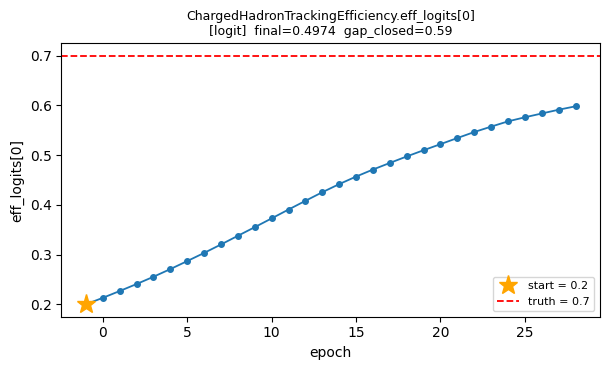

ChargedHadronTrackingEfficiency.eff_logits[0]: start=0.2 -> final=0.497415  (truth=0.7, gap_closed=0.59, correct direction, 29 epochs, early-stopped)


In [5]:
closure("ChargedHadronTrackingEfficiency.eff_logits[0]", 0.2)

### `ChargedHadronTrackingEfficiency.eff_logits[1]`

`truth = 0.95`  ·  kind = **logit**  ·  suggested init = `0.2`

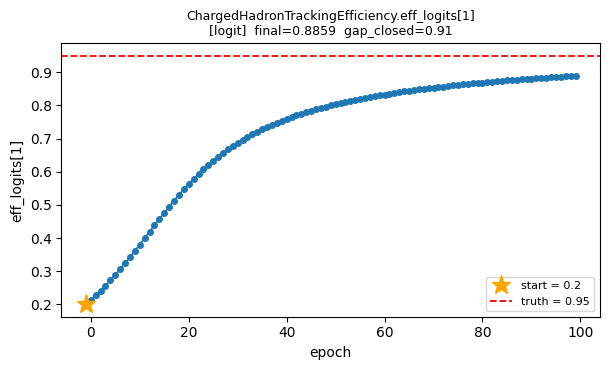

ChargedHadronTrackingEfficiency.eff_logits[1]: start=0.2 -> final=0.885853  (truth=0.95, gap_closed=0.91, correct direction, 100 epochs)


In [6]:
closure("ChargedHadronTrackingEfficiency.eff_logits[1]", 0.2)

### `ChargedHadronTrackingEfficiency.eff_logits[2]`

`truth = 0.6`  ·  kind = **logit**  ·  suggested init = `0.2`

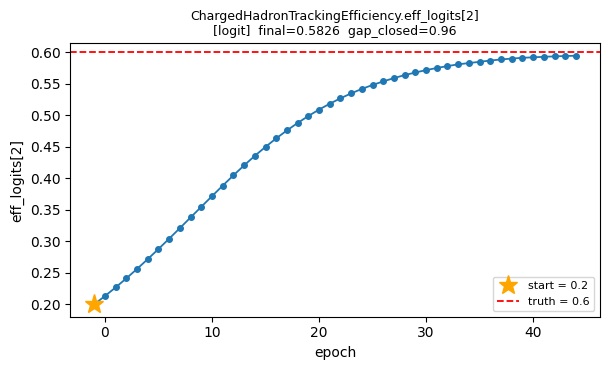

ChargedHadronTrackingEfficiency.eff_logits[2]: start=0.2 -> final=0.582574  (truth=0.6, gap_closed=0.96, correct direction, 45 epochs, early-stopped)


In [7]:
closure("ChargedHadronTrackingEfficiency.eff_logits[2]", 0.2)

### `ChargedHadronTrackingEfficiency.eff_logits[3]`

`truth = 0.85`  ·  kind = **logit**  ·  suggested init = `0.2`

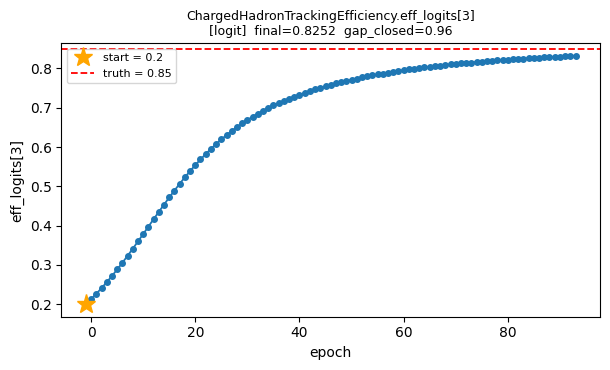

ChargedHadronTrackingEfficiency.eff_logits[3]: start=0.2 -> final=0.825155  (truth=0.85, gap_closed=0.96, correct direction, 94 epochs, early-stopped)


In [8]:
closure("ChargedHadronTrackingEfficiency.eff_logits[3]", 0.2)

# ElectronTrackingEfficiency

### `ElectronTrackingEfficiency.eff_logits[0]`

`truth = 0.73`  ·  kind = **logit**  ·  suggested init = `0.5`

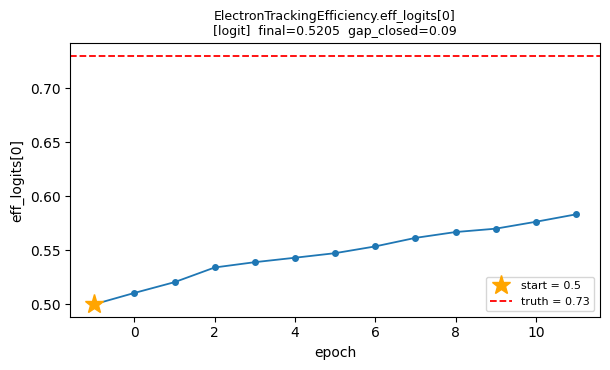

ElectronTrackingEfficiency.eff_logits[0]: start=0.5 -> final=0.520484  (truth=0.73, gap_closed=0.09, correct direction, 12 epochs, early-stopped)


In [9]:
closure("ElectronTrackingEfficiency.eff_logits[0]", 0.5)

### `ElectronTrackingEfficiency.eff_logits[1]`

`truth = 0.95`  ·  kind = **logit**  ·  suggested init = `0.2`

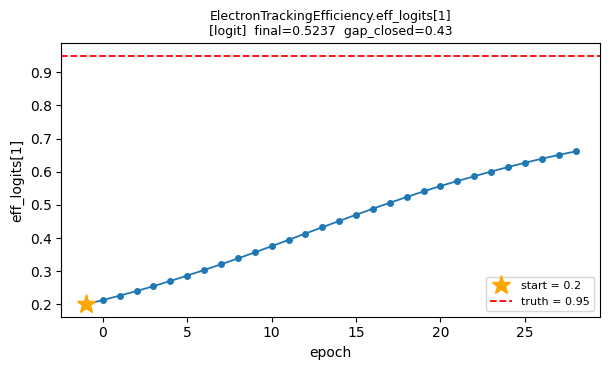

ElectronTrackingEfficiency.eff_logits[1]: start=0.2 -> final=0.523678  (truth=0.95, gap_closed=0.43, correct direction, 29 epochs, early-stopped)


In [10]:
closure("ElectronTrackingEfficiency.eff_logits[1]", 0.2)

### `ElectronTrackingEfficiency.eff_logits[2]`

`truth = 0.99`  ·  kind = **logit**  ·  suggested init = `0.2`

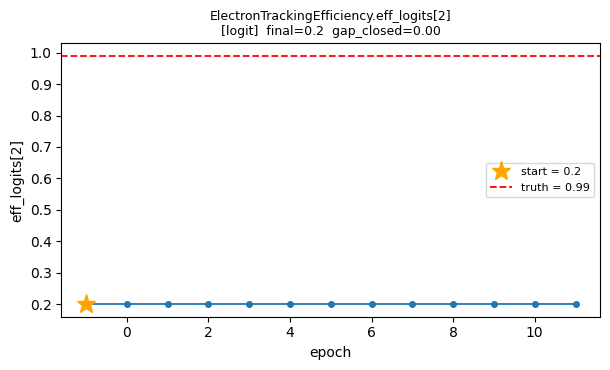

ElectronTrackingEfficiency.eff_logits[2]: start=0.2 -> final=0.2  (truth=0.99, gap_closed=0.00, WRONG direction, 12 epochs, early-stopped)


In [11]:
closure("ElectronTrackingEfficiency.eff_logits[2]", 0.2)

### `ElectronTrackingEfficiency.eff_logits[3]`

`truth = 0.5`  ·  kind = **logit**  ·  suggested init = `0.8`

training ElectronTrackingEfficiency.eff_logits[3]  (init=0.8, n_steps=100, n_events=5000, lr=0.01) ...
  -> ok in 260s


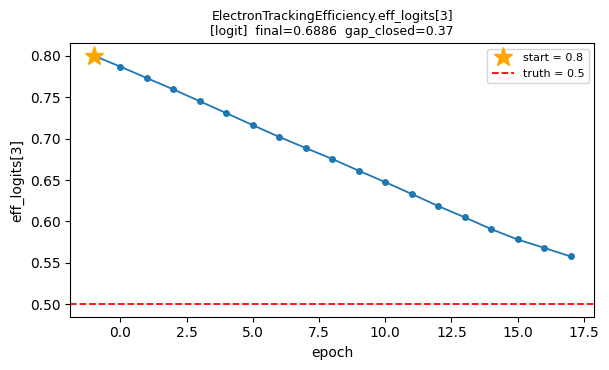

ElectronTrackingEfficiency.eff_logits[3]: start=0.8 -> final=0.688605  (truth=0.5, gap_closed=0.37, correct direction, 18 epochs, early-stopped)


In [12]:
closure("ElectronTrackingEfficiency.eff_logits[3]", 0.8)

In [ ]:
closure("ElectronTrackingEfficiency.eff_logits[3]", 0.3)

training ElectronTrackingEfficiency.eff_logits[3]  (init=0.3, n_steps=100, n_events=5000, lr=0.01) ...


### `ElectronTrackingEfficiency.eff_logits[4]`

`truth = 0.83`  ·  kind = **logit**  ·  suggested init = `0.2`

In [ ]:
closure("ElectronTrackingEfficiency.eff_logits[4]", 0.4)

### `ElectronTrackingEfficiency.eff_logits[5]`

`truth = 0.9`  ·  kind = **logit**  ·  suggested init = `0.2`

In [ ]:
closure("ElectronTrackingEfficiency.eff_logits[5]", 0.2)

# MuonTrackingEfficiency

### `MuonTrackingEfficiency.eff_logits[0]`

`truth = 0.75`  ·  kind = **logit**  ·  suggested init = `0.2`

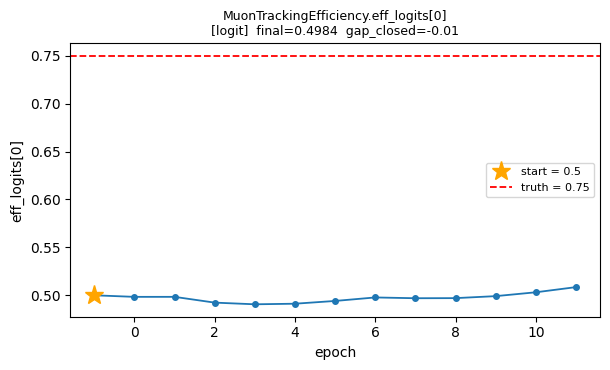

MuonTrackingEfficiency.eff_logits[0]: start=0.5 -> final=0.498377  (truth=0.75, gap_closed=-0.01, WRONG direction, 12 epochs, early-stopped)


In [16]:
closure("MuonTrackingEfficiency.eff_logits[0]", 0.5)

### `MuonTrackingEfficiency.eff_logits[1]`

`truth = 0.99`  ·  kind = **logit**  ·  suggested init = `0.2`

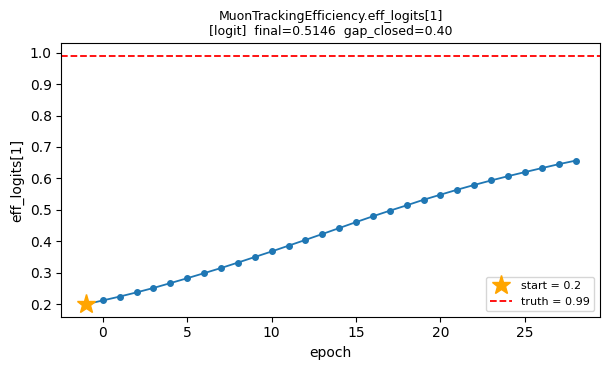

MuonTrackingEfficiency.eff_logits[1]: start=0.2 -> final=0.514566  (truth=0.99, gap_closed=0.40, correct direction, 29 epochs, early-stopped)


In [17]:
closure("MuonTrackingEfficiency.eff_logits[1]", 0.2)

### `MuonTrackingEfficiency.eff_logits[2]`

`truth = 0.99`  ·  kind = **logit**  ·  suggested init = `0.2`

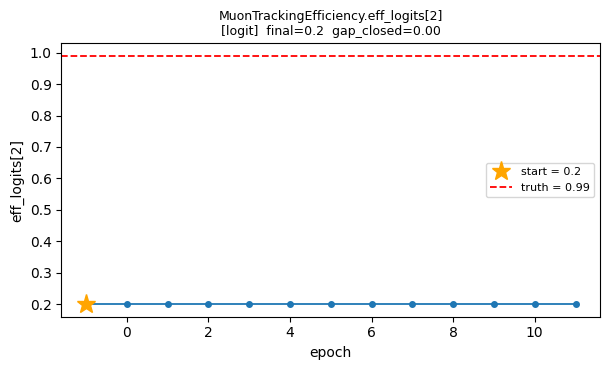

MuonTrackingEfficiency.eff_logits[2]: start=0.2 -> final=0.2  (truth=0.99, gap_closed=0.00, WRONG direction, 12 epochs, early-stopped)


In [18]:
closure("MuonTrackingEfficiency.eff_logits[2]", 0.2)

### `MuonTrackingEfficiency.eff_logits[3]`

`truth = 0.7`  ·  kind = **logit**  ·  suggested init = `0.2`

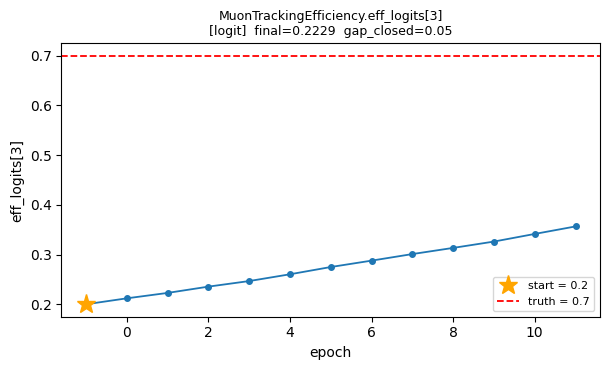

MuonTrackingEfficiency.eff_logits[3]: start=0.2 -> final=0.222858  (truth=0.7, gap_closed=0.05, correct direction, 12 epochs, early-stopped)


In [19]:
closure("MuonTrackingEfficiency.eff_logits[3]", 0.2)

### `MuonTrackingEfficiency.eff_logits[4]`

`truth = 0.98`  ·  kind = **logit**  ·  suggested init = `0.2`

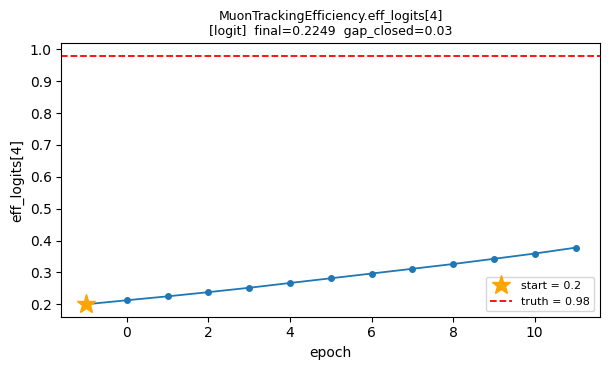

MuonTrackingEfficiency.eff_logits[4]: start=0.2 -> final=0.224946  (truth=0.98, gap_closed=0.03, correct direction, 12 epochs, early-stopped)


In [20]:
closure("MuonTrackingEfficiency.eff_logits[4]", 0.2)

### `MuonTrackingEfficiency.eff_logits[5]`

`truth = 0.98`  ·  kind = **logit**  ·  suggested init = `0.2`

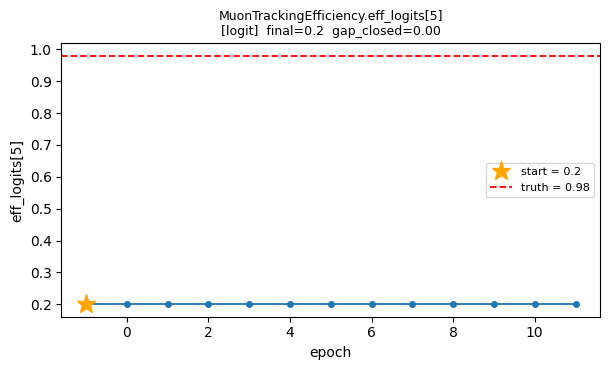

MuonTrackingEfficiency.eff_logits[5]: start=0.2 -> final=0.2  (truth=0.98, gap_closed=0.00, WRONG direction, 12 epochs, early-stopped)


In [21]:
closure("MuonTrackingEfficiency.eff_logits[5]", 0.2)

### `MuonTrackingEfficiency.rate_raw[0]`

`truth = 0.0005`  ·  kind = **softplus**  ·  suggested init = `0.0002`

> **Known-hard:** no gradient path when fit alone — expect `no gradient path -> cannot be fit alone` (not a bug).

In [22]:
closure("MuonTrackingEfficiency.rate_raw[0]", 0.0002)

training MuonTrackingEfficiency.rate_raw[0]  (init=0.0002, n_steps=100, n_events=5000, lr=0.01) ...
  -> no_grad in 301s
[MuonTrackingEfficiency.rate_raw[0]] no gradient path -> this parameter cannot be fit alone


### `MuonTrackingEfficiency.rate_raw[1]`

`truth = 0.0005`  ·  kind = **softplus**  ·  suggested init = `0.0002`

> **Known-hard:** no gradient path when fit alone — expect `no gradient path -> cannot be fit alone` (not a bug).

In [23]:
closure("MuonTrackingEfficiency.rate_raw[1]", 0.0002)

training MuonTrackingEfficiency.rate_raw[1]  (init=0.0002, n_steps=100, n_events=5000, lr=0.01) ...
  -> no_grad in 282s
[MuonTrackingEfficiency.rate_raw[1]] no gradient path -> this parameter cannot be fit alone


# ChargedHadronMomentumSmearing

### `ChargedHadronMomentumSmearing.resolution_module.a_raw[0]`

`truth = 0.06`  ·  kind = **softplus**  ·  suggested init = `0.024`

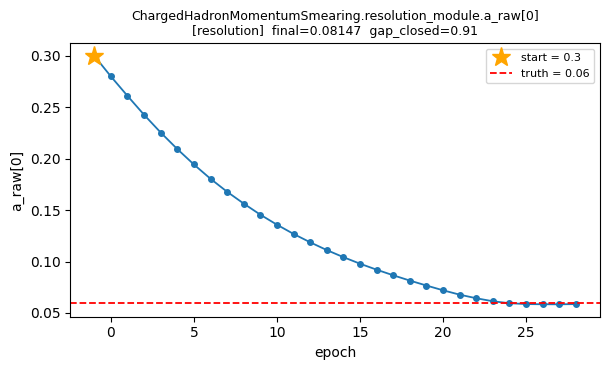

ChargedHadronMomentumSmearing.resolution_module.a_raw[0]: start=0.3 -> final=0.0814719  (truth=0.06, gap_closed=0.91, correct direction, 29 epochs, early-stopped)


In [24]:
closure("ChargedHadronMomentumSmearing.resolution_module.a_raw[0]", 0.3)

### `ChargedHadronMomentumSmearing.resolution_module.a_raw[1]`

`truth = 0.1`  ·  kind = **softplus**  ·  suggested init = `0.04`

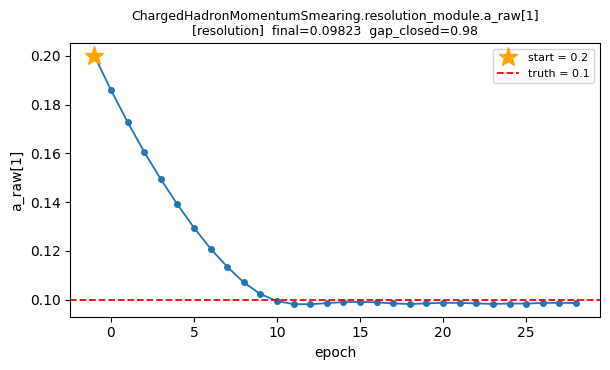

ChargedHadronMomentumSmearing.resolution_module.a_raw[1]: start=0.2 -> final=0.0982307  (truth=0.1, gap_closed=0.98, correct direction, 29 epochs, early-stopped)


In [25]:
closure("ChargedHadronMomentumSmearing.resolution_module.a_raw[1]", 0.2)

### `ChargedHadronMomentumSmearing.resolution_module.a_raw[2]`

`truth = 0.25`  ·  kind = **softplus**  ·  suggested init = `0.1`

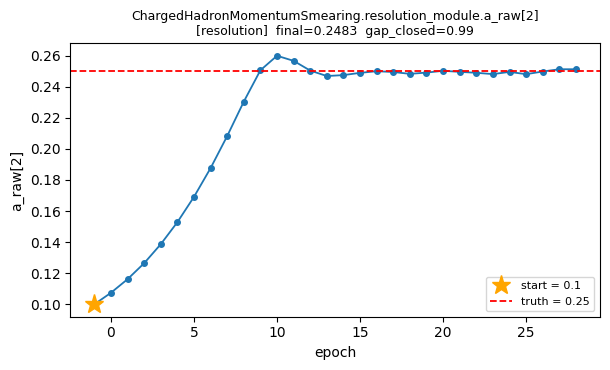

ChargedHadronMomentumSmearing.resolution_module.a_raw[2]: start=0.1 -> final=0.248298  (truth=0.25, gap_closed=0.99, correct direction, 29 epochs, early-stopped)


In [26]:
closure("ChargedHadronMomentumSmearing.resolution_module.a_raw[2]", 0.1)

### `ChargedHadronMomentumSmearing.resolution_module.b_raw[0]`

`truth = 0.0013`  ·  kind = **softplus**  ·  suggested init = `0.00052`

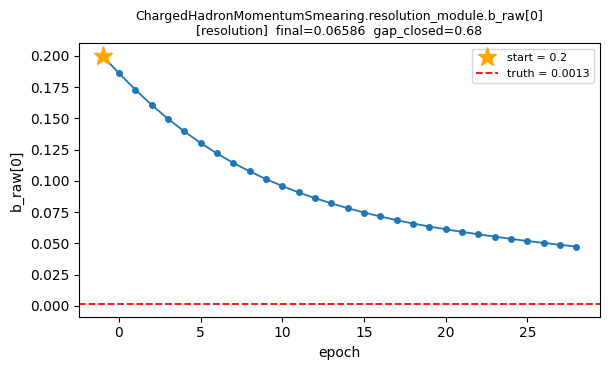

ChargedHadronMomentumSmearing.resolution_module.b_raw[0]: start=0.2 -> final=0.0658618  (truth=0.0013, gap_closed=0.68, correct direction, 29 epochs, early-stopped)


In [27]:
closure("ChargedHadronMomentumSmearing.resolution_module.b_raw[0]", 0.2)

### `ChargedHadronMomentumSmearing.resolution_module.b_raw[1]`

`truth = 0.0017`  ·  kind = **softplus**  ·  suggested init = `0.00068`

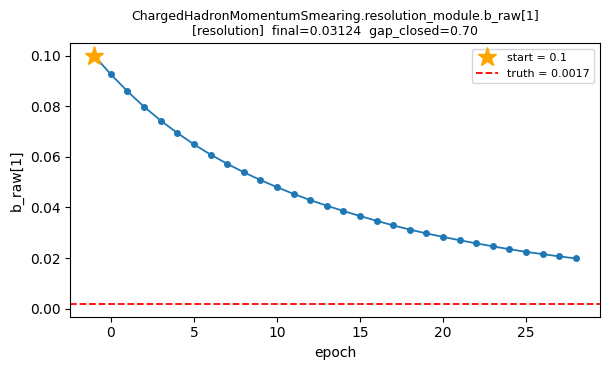

ChargedHadronMomentumSmearing.resolution_module.b_raw[1]: start=0.1 -> final=0.0312398  (truth=0.0017, gap_closed=0.70, correct direction, 29 epochs, early-stopped)


In [28]:
closure("ChargedHadronMomentumSmearing.resolution_module.b_raw[1]", 0.1)

### `ChargedHadronMomentumSmearing.resolution_module.b_raw[2]`

`truth = 0.0031`  ·  kind = **softplus**  ·  suggested init = `0.00124`

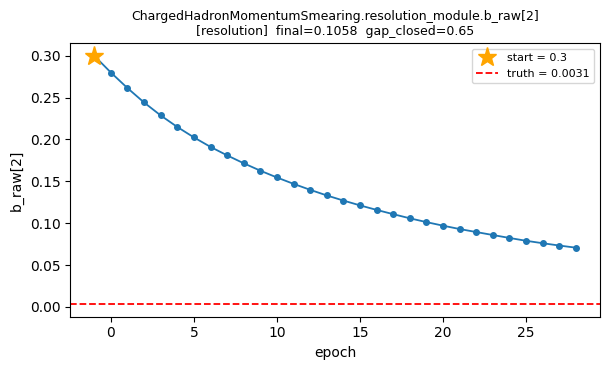

ChargedHadronMomentumSmearing.resolution_module.b_raw[2]: start=0.3 -> final=0.105835  (truth=0.0031, gap_closed=0.65, correct direction, 29 epochs, early-stopped)


In [29]:
closure("ChargedHadronMomentumSmearing.resolution_module.b_raw[2]", 0.3)

### `ChargedHadronMomentumSmearing.resolution_module.scale_raw[0]`

`truth = 1.25`  ·  kind = **scale**  ·  suggested init = `0.78`

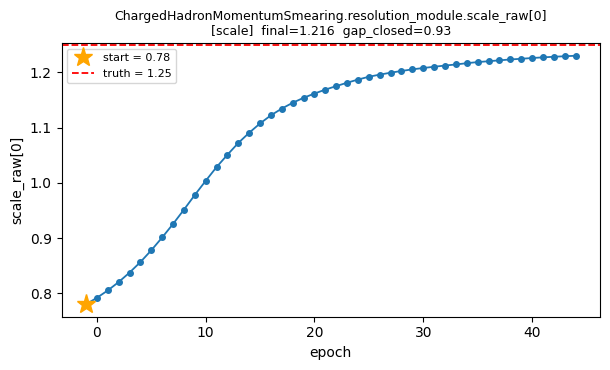

ChargedHadronMomentumSmearing.resolution_module.scale_raw[0]: start=0.78 -> final=1.21646  (truth=1.25, gap_closed=0.93, correct direction, 45 epochs, early-stopped)


In [30]:
closure("ChargedHadronMomentumSmearing.resolution_module.scale_raw[0]", 0.78)

### `ChargedHadronMomentumSmearing.resolution_module.scale_raw[1]`

`truth = 1.25`  ·  kind = **scale**  ·  suggested init = `0.78`

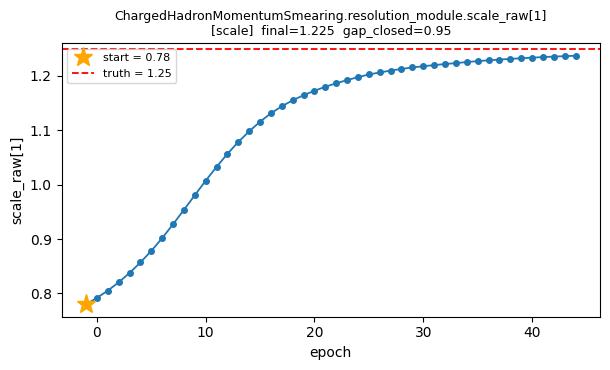

ChargedHadronMomentumSmearing.resolution_module.scale_raw[1]: start=0.78 -> final=1.2254  (truth=1.25, gap_closed=0.95, correct direction, 45 epochs, early-stopped)


In [31]:
closure("ChargedHadronMomentumSmearing.resolution_module.scale_raw[1]", 0.78)

### `ChargedHadronMomentumSmearing.resolution_module.scale_raw[2]`

`truth = 1.25`  ·  kind = **scale**  ·  suggested init = `0.78`

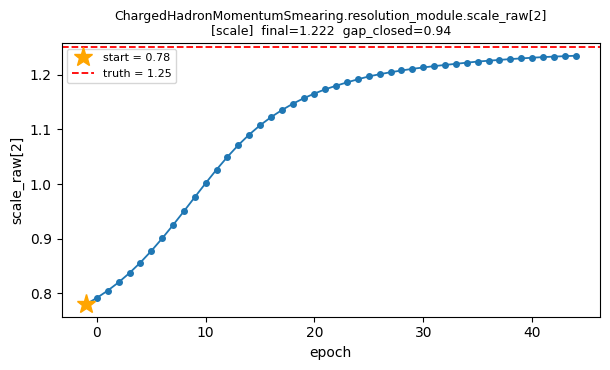

ChargedHadronMomentumSmearing.resolution_module.scale_raw[2]: start=0.78 -> final=1.22197  (truth=1.25, gap_closed=0.94, correct direction, 45 epochs, early-stopped)


In [32]:
closure("ChargedHadronMomentumSmearing.resolution_module.scale_raw[2]", 0.78)

# ElectronMomentumSmearing

### `ElectronMomentumSmearing.resolution_module.a_raw[0]`

`truth = 0.03`  ·  kind = **softplus**  ·  suggested init = `0.012`

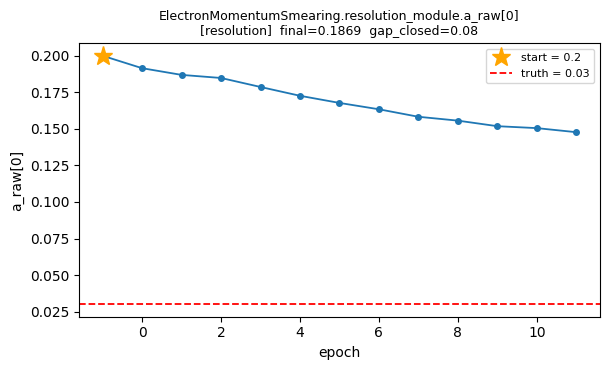

ElectronMomentumSmearing.resolution_module.a_raw[0]: start=0.2 -> final=0.186915  (truth=0.03, gap_closed=0.08, correct direction, 12 epochs, early-stopped)


In [33]:
closure("ElectronMomentumSmearing.resolution_module.a_raw[0]", 0.2)

### `ElectronMomentumSmearing.resolution_module.a_raw[1]`

`truth = 0.05`  ·  kind = **softplus**  ·  suggested init = `0.02`

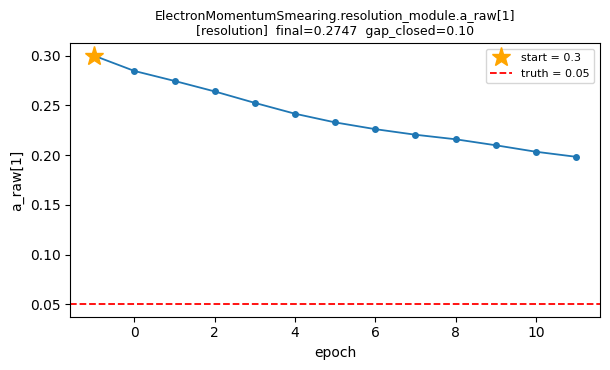

ElectronMomentumSmearing.resolution_module.a_raw[1]: start=0.3 -> final=0.27467  (truth=0.05, gap_closed=0.10, correct direction, 12 epochs, early-stopped)


In [34]:
closure("ElectronMomentumSmearing.resolution_module.a_raw[1]", 0.3)

### `ElectronMomentumSmearing.resolution_module.a_raw[2]`

`truth = 0.15`  ·  kind = **softplus**  ·  suggested init = `0.06`

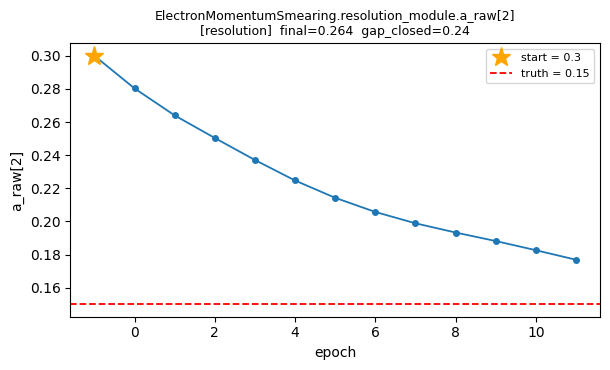

ElectronMomentumSmearing.resolution_module.a_raw[2]: start=0.3 -> final=0.264013  (truth=0.15, gap_closed=0.24, correct direction, 12 epochs, early-stopped)


In [35]:
closure("ElectronMomentumSmearing.resolution_module.a_raw[2]", 0.3)

### `ElectronMomentumSmearing.resolution_module.b_raw[0]`

`truth = 0.0013`  ·  kind = **softplus**  ·  suggested init = `0.00052`

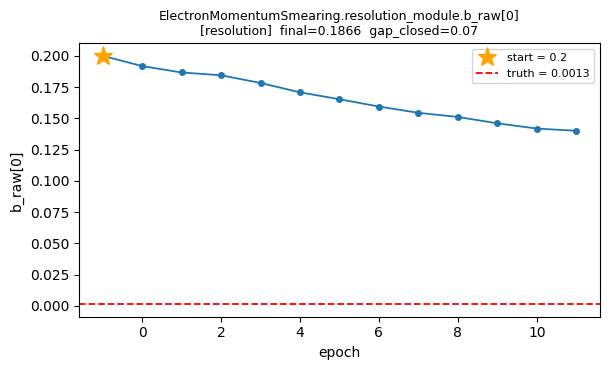

ElectronMomentumSmearing.resolution_module.b_raw[0]: start=0.2 -> final=0.186639  (truth=0.0013, gap_closed=0.07, correct direction, 12 epochs, early-stopped)


In [36]:
closure("ElectronMomentumSmearing.resolution_module.b_raw[0]", 0.2)

### `ElectronMomentumSmearing.resolution_module.b_raw[1]`

`truth = 0.0017`  ·  kind = **softplus**  ·  suggested init = `0.00068`

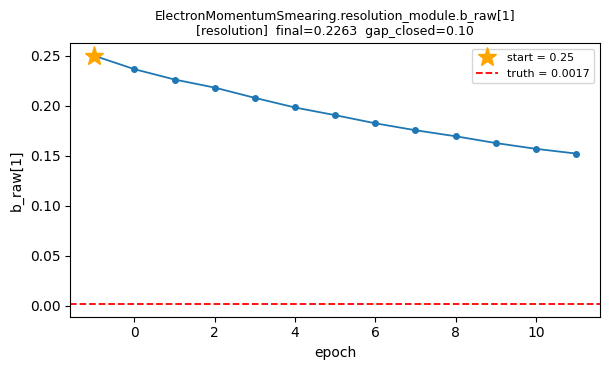

ElectronMomentumSmearing.resolution_module.b_raw[1]: start=0.25 -> final=0.226268  (truth=0.0017, gap_closed=0.10, correct direction, 12 epochs, early-stopped)


In [37]:
closure("ElectronMomentumSmearing.resolution_module.b_raw[1]", 0.25)

### `ElectronMomentumSmearing.resolution_module.b_raw[2]`

`truth = 0.0031`  ·  kind = **softplus**  ·  suggested init = `0.00124`

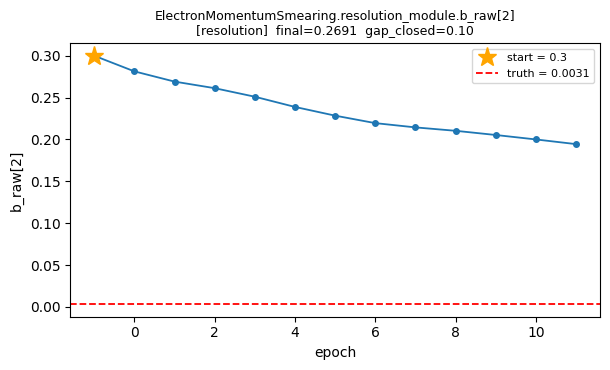

ElectronMomentumSmearing.resolution_module.b_raw[2]: start=0.3 -> final=0.26913  (truth=0.0031, gap_closed=0.10, correct direction, 12 epochs, early-stopped)


In [38]:
closure("ElectronMomentumSmearing.resolution_module.b_raw[2]", 0.3)

### `ElectronMomentumSmearing.resolution_module.scale_raw[0]`

`truth = 1`  ·  kind = **scale**  ·  suggested init = `0.78`

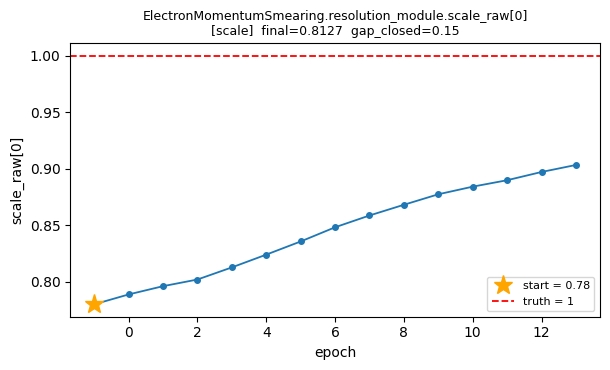

ElectronMomentumSmearing.resolution_module.scale_raw[0]: start=0.78 -> final=0.812668  (truth=1, gap_closed=0.15, correct direction, 14 epochs, early-stopped)


In [39]:
closure("ElectronMomentumSmearing.resolution_module.scale_raw[0]", 0.78)

### `ElectronMomentumSmearing.resolution_module.scale_raw[1]`

`truth = 1`  ·  kind = **scale**  ·  suggested init = `0.78`

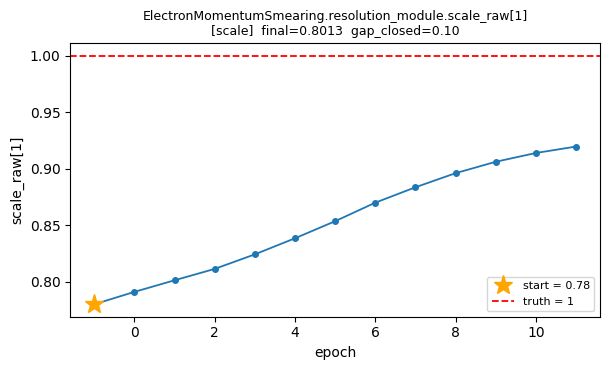

ElectronMomentumSmearing.resolution_module.scale_raw[1]: start=0.78 -> final=0.801255  (truth=1, gap_closed=0.10, correct direction, 12 epochs, early-stopped)


In [40]:
closure("ElectronMomentumSmearing.resolution_module.scale_raw[1]", 0.78)

### `ElectronMomentumSmearing.resolution_module.scale_raw[2]`

`truth = 1`  ·  kind = **scale**  ·  suggested init = `0.78`

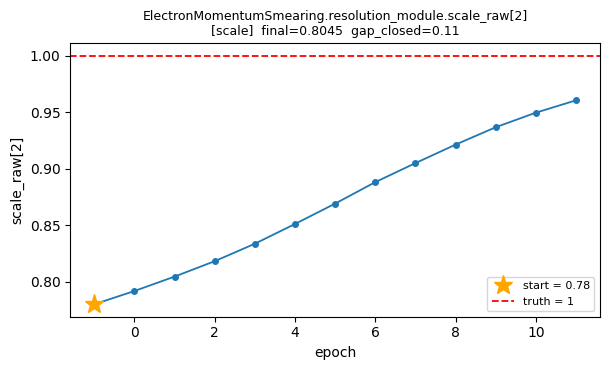

ElectronMomentumSmearing.resolution_module.scale_raw[2]: start=0.78 -> final=0.804515  (truth=1, gap_closed=0.11, correct direction, 12 epochs, early-stopped)


In [41]:
closure("ElectronMomentumSmearing.resolution_module.scale_raw[2]", 0.78)

# MuonMomentumSmearing

### `MuonMomentumSmearing.resolution_module.a_raw[0]`

`truth = 0.01`  ·  kind = **softplus**  ·  suggested init = `0.004`

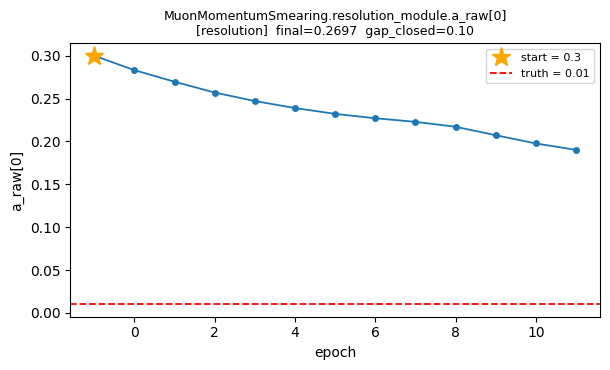

MuonMomentumSmearing.resolution_module.a_raw[0]: start=0.3 -> final=0.269705  (truth=0.01, gap_closed=0.10, correct direction, 12 epochs, early-stopped)


In [42]:
closure("MuonMomentumSmearing.resolution_module.a_raw[0]", 0.3)

### `MuonMomentumSmearing.resolution_module.a_raw[1]`

`truth = 0.02`  ·  kind = **softplus**  ·  suggested init = `0.008`

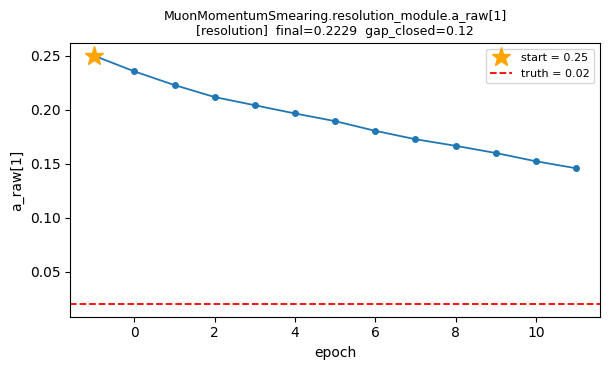

MuonMomentumSmearing.resolution_module.a_raw[1]: start=0.25 -> final=0.222858  (truth=0.02, gap_closed=0.12, correct direction, 12 epochs, early-stopped)


In [43]:
closure("MuonMomentumSmearing.resolution_module.a_raw[1]", 0.25)

### `MuonMomentumSmearing.resolution_module.a_raw[2]`

`truth = 0.1`  ·  kind = **softplus**  ·  suggested init = `0.04`

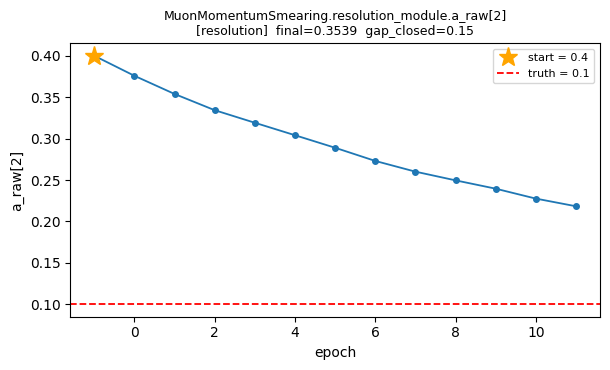

MuonMomentumSmearing.resolution_module.a_raw[2]: start=0.4 -> final=0.353897  (truth=0.1, gap_closed=0.15, correct direction, 12 epochs, early-stopped)


In [44]:
closure("MuonMomentumSmearing.resolution_module.a_raw[2]", 0.4)

### `MuonMomentumSmearing.resolution_module.b_raw[0]`

`truth = 0.001`  ·  kind = **softplus**  ·  suggested init = `0.0004`

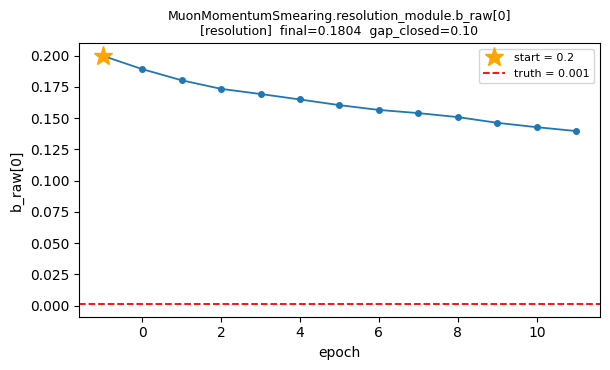

MuonMomentumSmearing.resolution_module.b_raw[0]: start=0.2 -> final=0.180378  (truth=0.001, gap_closed=0.10, correct direction, 12 epochs, early-stopped)


In [45]:
closure("MuonMomentumSmearing.resolution_module.b_raw[0]", 0.2)

### `MuonMomentumSmearing.resolution_module.b_raw[1]`

`truth = 0.0013`  ·  kind = **softplus**  ·  suggested init = `0.00052`

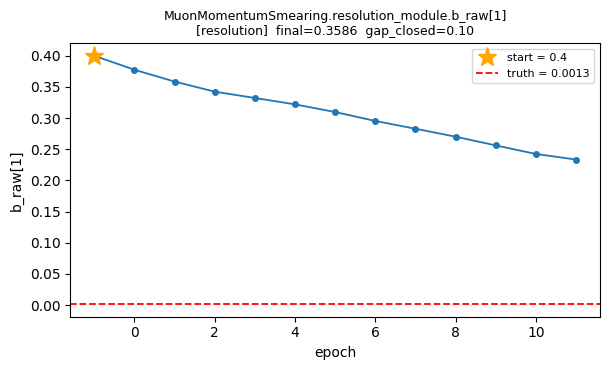

MuonMomentumSmearing.resolution_module.b_raw[1]: start=0.4 -> final=0.358633  (truth=0.0013, gap_closed=0.10, correct direction, 12 epochs, early-stopped)


In [46]:
closure("MuonMomentumSmearing.resolution_module.b_raw[1]", 0.4)

### `MuonMomentumSmearing.resolution_module.b_raw[2]`

`truth = 0.002`  ·  kind = **softplus**  ·  suggested init = `0.0008`

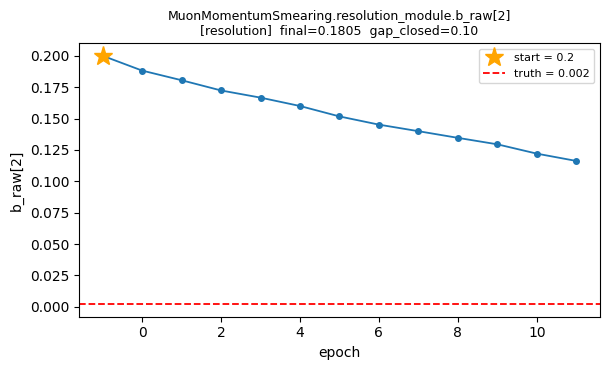

MuonMomentumSmearing.resolution_module.b_raw[2]: start=0.2 -> final=0.180506  (truth=0.002, gap_closed=0.10, correct direction, 12 epochs, early-stopped)


In [47]:
closure("MuonMomentumSmearing.resolution_module.b_raw[2]", 0.2)

### `MuonMomentumSmearing.resolution_module.scale_raw[0]`

`truth = 1`  ·  kind = **scale**  ·  suggested init = `0.78`

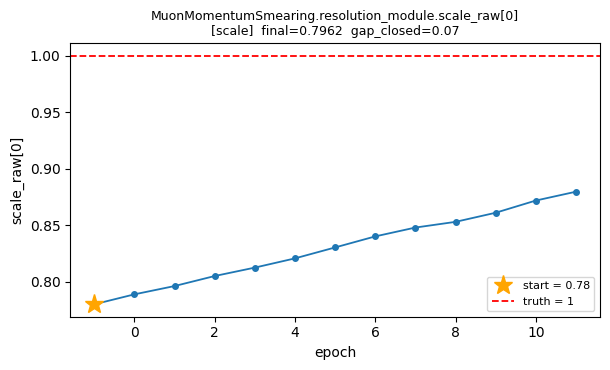

MuonMomentumSmearing.resolution_module.scale_raw[0]: start=0.78 -> final=0.796153  (truth=1, gap_closed=0.07, correct direction, 12 epochs, early-stopped)


In [48]:
closure("MuonMomentumSmearing.resolution_module.scale_raw[0]", 0.78)

### `MuonMomentumSmearing.resolution_module.scale_raw[1]`

`truth = 1`  ·  kind = **scale**  ·  suggested init = `0.78`

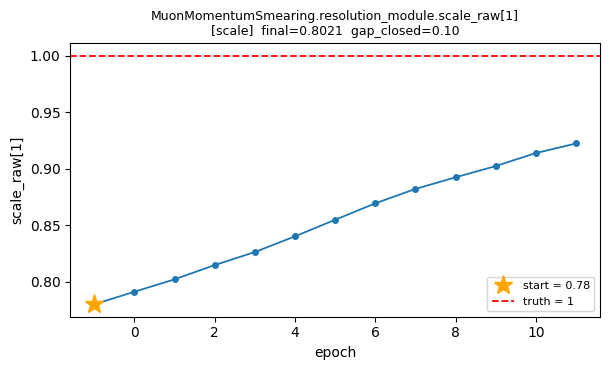

MuonMomentumSmearing.resolution_module.scale_raw[1]: start=0.78 -> final=0.8021  (truth=1, gap_closed=0.10, correct direction, 12 epochs, early-stopped)


In [49]:
closure("MuonMomentumSmearing.resolution_module.scale_raw[1]", 0.78)

### `MuonMomentumSmearing.resolution_module.scale_raw[2]`

`truth = 1`  ·  kind = **scale**  ·  suggested init = `0.78`

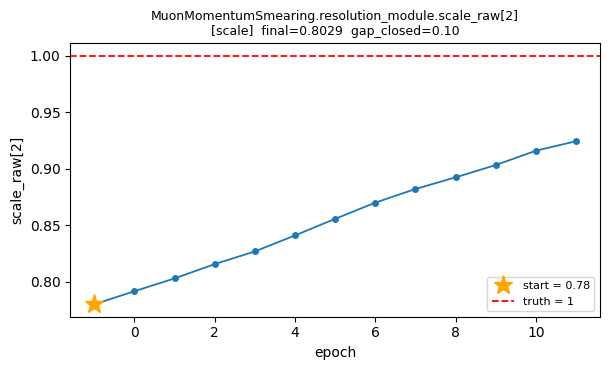

MuonMomentumSmearing.resolution_module.scale_raw[2]: start=0.78 -> final=0.802909  (truth=1, gap_closed=0.10, correct direction, 12 epochs, early-stopped)


In [50]:
closure("MuonMomentumSmearing.resolution_module.scale_raw[2]", 0.78)

# HadronFractions

### `HadronFractions.chad_logit`

`truth = 1e-06`  ·  kind = **logit**  ·  suggested init = `0.8`

> **Known-hard:** truth `1e-6` sits in the dead-gradient sigmoid tail — expect it to barely move (low `gap_closed`).

training HadronFractions.chad_logit  (init=0.8, n_steps=100, n_events=5000, lr=0.01) ...
  -> ok in 436s


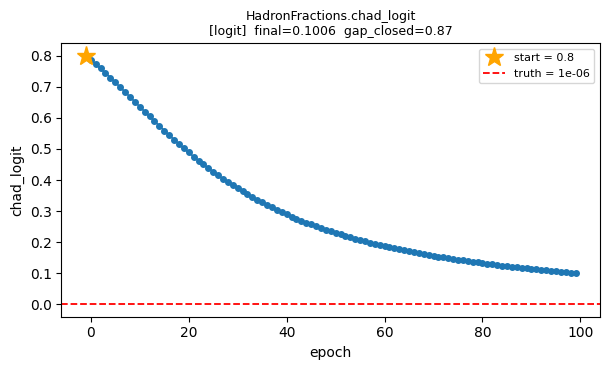

HadronFractions.chad_logit: start=0.8 -> final=0.10064  (truth=1e-06, gap_closed=0.87, correct direction, 100 epochs)


In [51]:
closure("HadronFractions.chad_logit", 0.8)

### `HadronFractions.k0s_logit`

`truth = 0.3`  ·  kind = **logit**  ·  suggested init = `0.8`

training HadronFractions.k0s_logit  (init=0.8, n_steps=100, n_events=5000, lr=0.01) ...
  -> ok in 189s


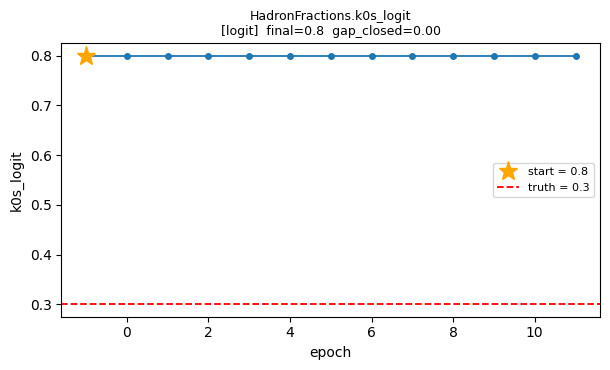

HadronFractions.k0s_logit: start=0.8 -> final=0.8  (truth=0.3, gap_closed=0.00, WRONG direction, 12 epochs, early-stopped)


In [52]:
closure("HadronFractions.k0s_logit", 0.8)

### `HadronFractions.lambda_logit`

`truth = 0.3`  ·  kind = **logit**  ·  suggested init = `0.8`

training HadronFractions.lambda_logit  (init=0.8, n_steps=100, n_events=5000, lr=0.01) ...
  -> ok in 322s


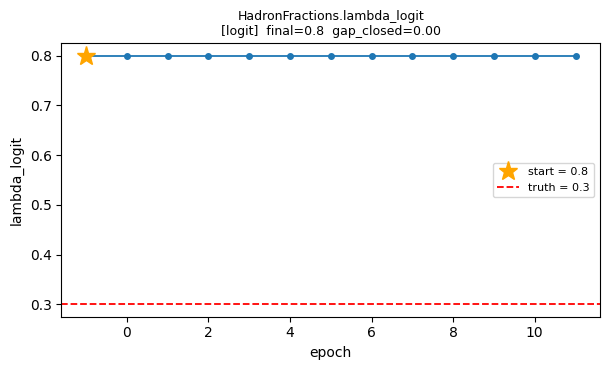

HadronFractions.lambda_logit: start=0.8 -> final=0.8  (truth=0.3, gap_closed=0.00, WRONG direction, 12 epochs, early-stopped)


In [53]:
closure("HadronFractions.lambda_logit", 0.8)

# ECal

### `ECal.scale_module.scale_raw[0]`

`truth = 1.2`  ·  kind = **scale**  ·  suggested init = `0.78`

training ECal.scale_module.scale_raw[0]  (init=0.78, n_steps=100, n_events=5000, lr=0.01) ...
  -> ok in 235s


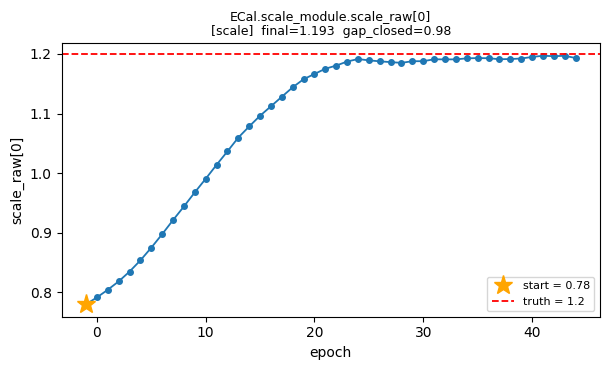

ECal.scale_module.scale_raw[0]: start=0.78 -> final=1.19251  (truth=1.2, gap_closed=0.98, correct direction, 45 epochs, early-stopped)


In [54]:
closure("ECal.scale_module.scale_raw[0]", 0.78)

### `ECal.scale_module.scale_raw[1]`

`truth = 1.2`  ·  kind = **scale**  ·  suggested init = `0.78`

training ECal.scale_module.scale_raw[1]  (init=0.78, n_steps=100, n_events=5000, lr=0.01) ...
  -> ok in 310s


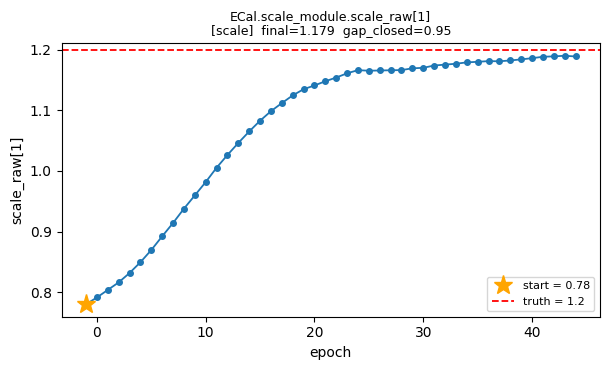

ECal.scale_module.scale_raw[1]: start=0.78 -> final=1.17921  (truth=1.2, gap_closed=0.95, correct direction, 45 epochs, early-stopped)


In [55]:
closure("ECal.scale_module.scale_raw[1]", 0.78)

### `ECal.scale_module.scale_raw[2]`

`truth = 1.2`  ·  kind = **scale**  ·  suggested init = `0.78`

training ECal.scale_module.scale_raw[2]  (init=0.78, n_steps=100, n_events=5000, lr=0.01) ...
  -> ok in 281s


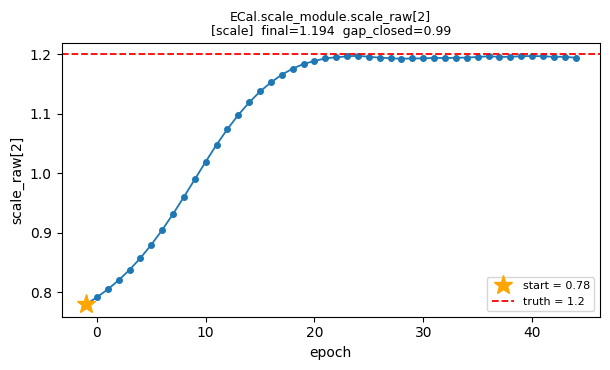

ECal.scale_module.scale_raw[2]: start=0.78 -> final=1.19437  (truth=1.2, gap_closed=0.99, correct direction, 45 epochs, early-stopped)


In [56]:
closure("ECal.scale_module.scale_raw[2]", 0.78)

### `ECal.resolution_func.common_c_E`

`truth = 0.008`  ·  kind = **softplus**  ·  suggested init = `0.0032`

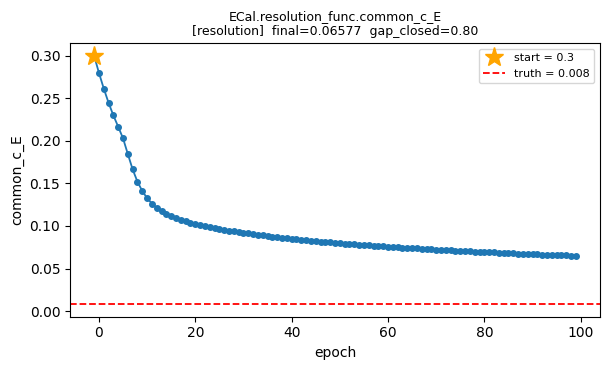

ECal.resolution_func.common_c_E: start=0.3 -> final=0.0657714  (truth=0.008, gap_closed=0.80, correct direction, 100 epochs)


In [6]:
closure("ECal.resolution_func.common_c_E", 0.3)

### `ECal.resolution_func.common_c_S`

`truth = 0.11`  ·  kind = **softplus**  ·  suggested init = `0.044`

  -> ok in 384s


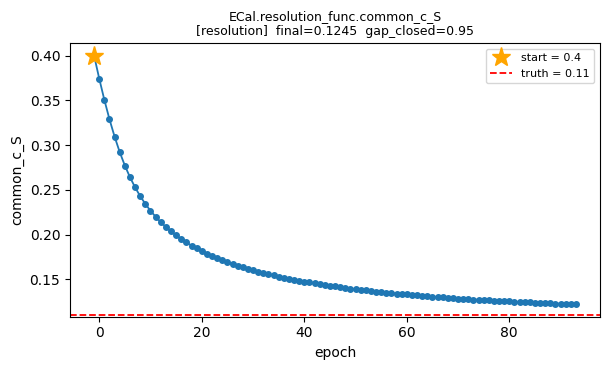

ECal.resolution_func.common_c_S: start=0.4 -> final=0.124456  (truth=0.11, gap_closed=0.95, correct direction, 94 epochs, early-stopped)


In [58]:
closure("ECal.resolution_func.common_c_S", 0.4)

### `ECal.resolution_func.common_c_N`

`truth = 0.4`  ·  kind = **softplus**  ·  suggested init = `0.16`

training ECal.resolution_func.common_c_N  (init=0.1, n_steps=100, n_events=5000, lr=0.01) ...
  -> ok in 138s


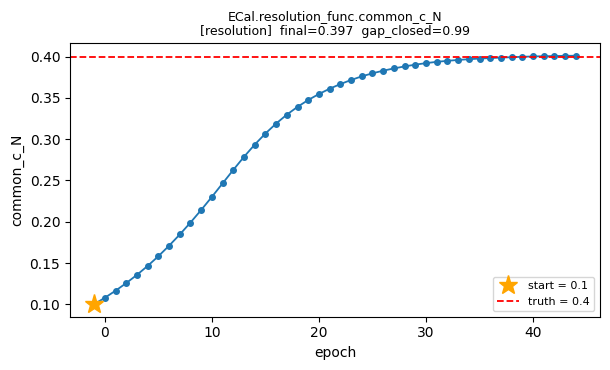

ECal.resolution_func.common_c_N: start=0.1 -> final=0.396967  (truth=0.4, gap_closed=0.99, correct direction, 45 epochs, early-stopped)


In [59]:
closure("ECal.resolution_func.common_c_N", 0.1)

### `ECal.resolution_func.barrel_a`

`truth = 1`  ·  kind = **softplus**  ·  suggested init = `0.4`

training ECal.resolution_func.barrel_a  (init=0.4, n_steps=100, n_events=5000, lr=0.01) ...
  -> ok in 267s


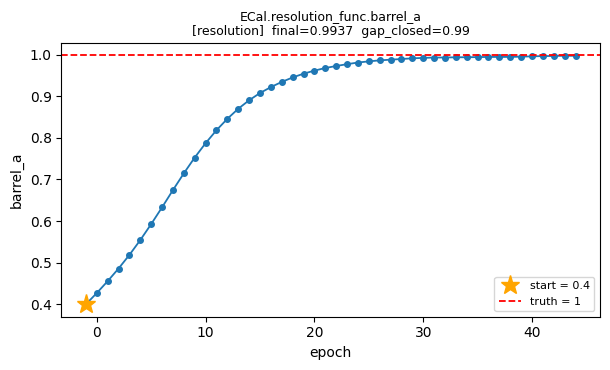

ECal.resolution_func.barrel_a: start=0.4 -> final=0.993667  (truth=1, gap_closed=0.99, correct direction, 45 epochs, early-stopped)


In [60]:
closure("ECal.resolution_func.barrel_a", 0.4)

### `ECal.resolution_func.barrel_b`

`truth = 0.64`  ·  kind = **softplus**  ·  suggested init = `0.256`

training ECal.resolution_func.barrel_b  (init=0.2, n_steps=100, n_events=5000, lr=0.01) ...
  -> ok in 113s


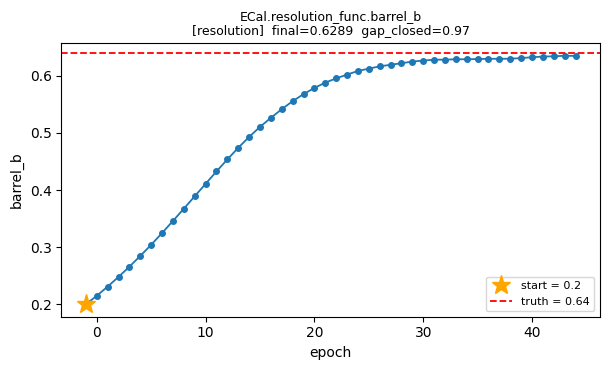

ECal.resolution_func.barrel_b: start=0.2 -> final=0.628887  (truth=0.64, gap_closed=0.97, correct direction, 45 epochs, early-stopped)


In [61]:
closure("ECal.resolution_func.barrel_b", 0.2)

### `ECal.resolution_func.endcap_a`

`truth = 2.16`  ·  kind = **softplus**  ·  suggested init = `0.864`

training ECal.resolution_func.endcap_a  (init=0.8, n_steps=100, n_events=5000, lr=0.01) ...
  -> ok in 153s


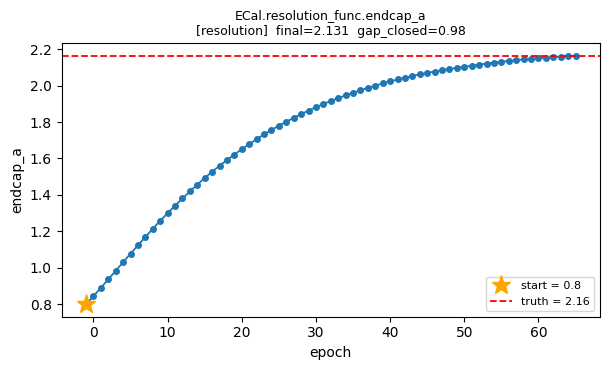

ECal.resolution_func.endcap_a: start=0.8 -> final=2.13091  (truth=2.16, gap_closed=0.98, correct direction, 66 epochs, early-stopped)


In [62]:
closure("ECal.resolution_func.endcap_a", 0.8)

### `ECal.resolution_func.endcap_b`

`truth = 5.6`  ·  kind = **softplus**  ·  suggested init = `2.24`

training ECal.resolution_func.endcap_b  (init=2, n_steps=100, n_events=5000, lr=0.01) ...
  -> ok in 115s


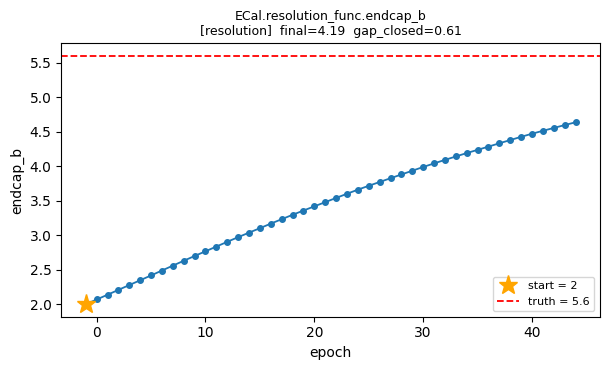

ECal.resolution_func.endcap_b: start=2 -> final=4.19025  (truth=5.6, gap_closed=0.61, correct direction, 45 epochs, early-stopped)


In [63]:
closure("ECal.resolution_func.endcap_b", 2.0)

### `ECal.resolution_func.forward_c_E`

`truth = 0.107`  ·  kind = **softplus**  ·  suggested init = `0.0428`

training ECal.resolution_func.forward_c_E  (init=0.75, n_steps=100, n_events=5000, lr=0.01) ...
  -> ok in 180s


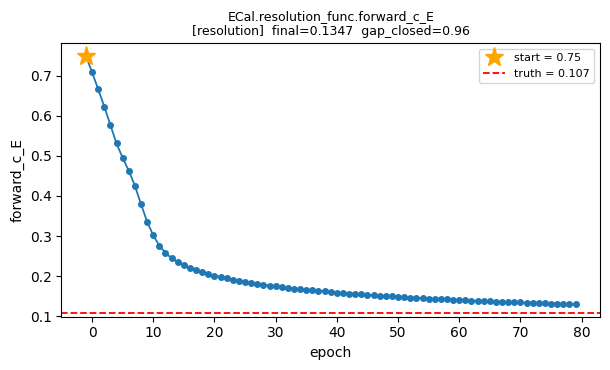

ECal.resolution_func.forward_c_E: start=0.75 -> final=0.13466  (truth=0.107, gap_closed=0.96, correct direction, 80 epochs, early-stopped)


In [64]:
closure("ECal.resolution_func.forward_c_E", 0.75)

### `ECal.resolution_func.forward_c_S`

`truth = 2.08`  ·  kind = **softplus**  ·  suggested init = `0.832`

training ECal.resolution_func.forward_c_S  (init=0.75, n_steps=100, n_events=5000, lr=0.01) ...
  -> ok in 218s


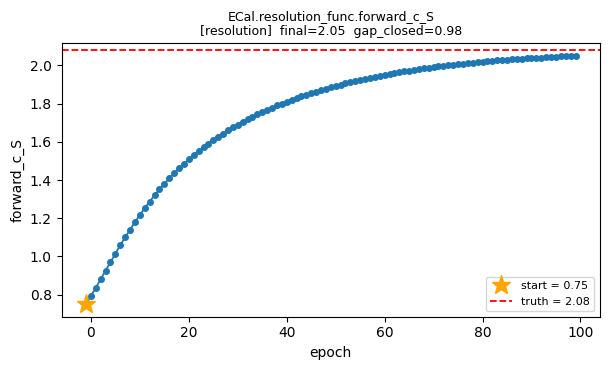

ECal.resolution_func.forward_c_S: start=0.75 -> final=2.04991  (truth=2.08, gap_closed=0.98, correct direction, 100 epochs)


In [65]:
closure("ECal.resolution_func.forward_c_S", 0.75)

# HCal

### `HCal.scale_module.scale_raw[0]`

`truth = 0.9`  ·  kind = **scale**  ·  suggested init = `1.2`

training HCal.scale_module.scale_raw[0]  (init=1.2, n_steps=100, n_events=5000, lr=0.01) ...
  -> ok in 166s


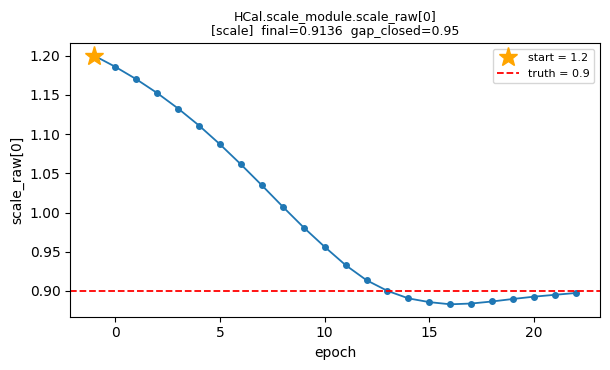

HCal.scale_module.scale_raw[0]: start=1.2 -> final=0.913614  (truth=0.9, gap_closed=0.95, correct direction, 23 epochs, early-stopped)


In [66]:
closure("HCal.scale_module.scale_raw[0]", 1.2)

### `HCal.scale_module.scale_raw[1]`

`truth = 0.9`  ·  kind = **scale**  ·  suggested init = `1.2`

training HCal.scale_module.scale_raw[1]  (init=1.2, n_steps=100, n_events=5000, lr=0.01) ...
  -> ok in 91s


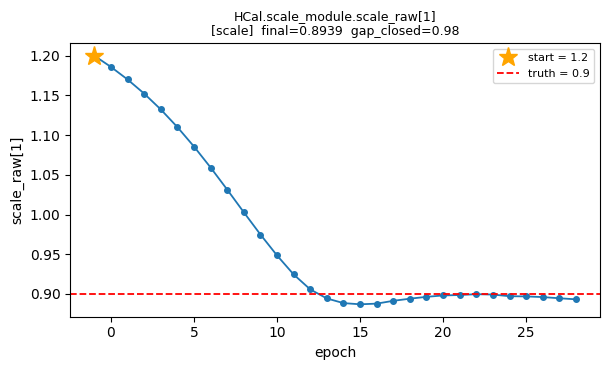

HCal.scale_module.scale_raw[1]: start=1.2 -> final=0.893947  (truth=0.9, gap_closed=0.98, correct direction, 29 epochs, early-stopped)


In [67]:
closure("HCal.scale_module.scale_raw[1]", 1.2)

### `HCal.resolution_func.central_c_E`

`truth = 0.05`  ·  kind = **softplus**  ·  suggested init = `0.02`

training HCal.resolution_func.central_c_E  (init=0.4, n_steps=100, n_events=5000, lr=0.01) ...
  -> ok in 114s


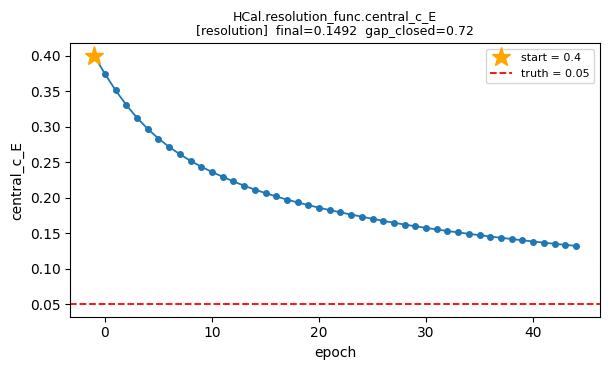

HCal.resolution_func.central_c_E: start=0.4 -> final=0.149241  (truth=0.05, gap_closed=0.72, correct direction, 45 epochs, early-stopped)


In [68]:
closure("HCal.resolution_func.central_c_E", 0.4)

### `HCal.resolution_func.central_c_S`

`truth = 1.5`  ·  kind = **softplus**  ·  suggested init = `0.6`

training HCal.resolution_func.central_c_S  (init=0.6, n_steps=100, n_events=5000, lr=0.01) ...
  -> ok in 96s


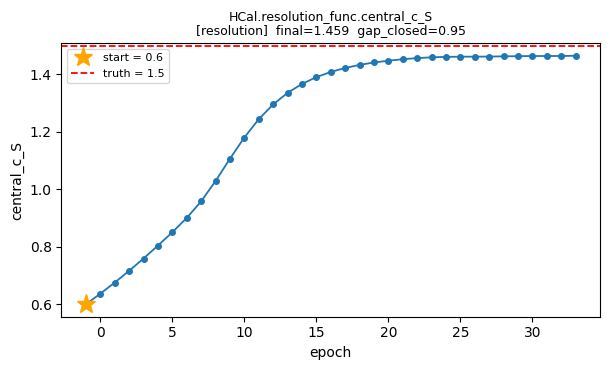

HCal.resolution_func.central_c_S: start=0.6 -> final=1.45944  (truth=1.5, gap_closed=0.95, correct direction, 34 epochs, early-stopped)


In [69]:
closure("HCal.resolution_func.central_c_S", 0.6)

### `HCal.resolution_func.forward_c_E`

`truth = 0.13`  ·  kind = **softplus**  ·  suggested init = `0.052`

training HCal.resolution_func.forward_c_E  (init=0.4, n_steps=100, n_events=5000, lr=0.01) ...
  -> ok in 109s


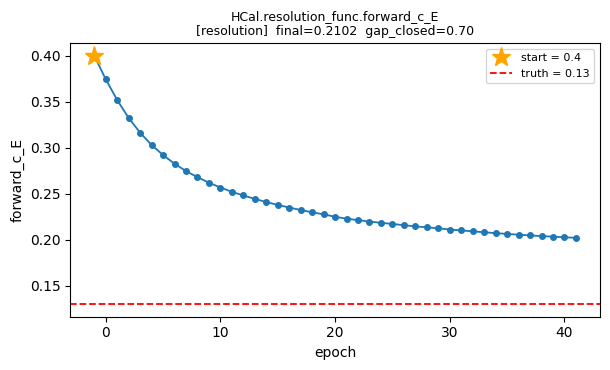

HCal.resolution_func.forward_c_E: start=0.4 -> final=0.210224  (truth=0.13, gap_closed=0.70, correct direction, 42 epochs, early-stopped)


In [70]:
closure("HCal.resolution_func.forward_c_E", 0.4)

### `HCal.resolution_func.forward_c_S`

`truth = 2.7`  ·  kind = **softplus**  ·  suggested init = `1.08`

training HCal.resolution_func.forward_c_S  (init=1.2, n_steps=100, n_events=5000, lr=0.01) ...
  -> ok in 143s


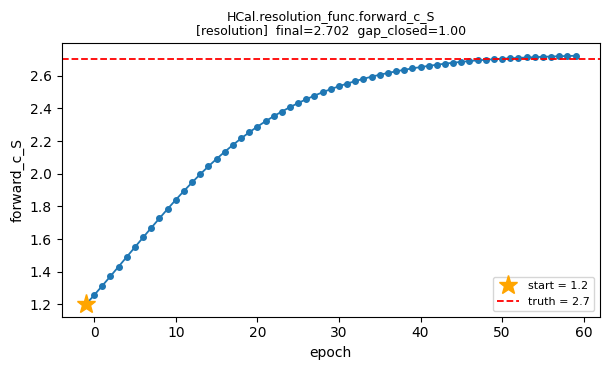

HCal.resolution_func.forward_c_S: start=1.2 -> final=2.70166  (truth=2.7, gap_closed=1.00, correct direction, 60 epochs, early-stopped)


In [71]:
closure("HCal.resolution_func.forward_c_S", 1.2)

training HCal.resolution_func.forward_c_S  (init=2, n_steps=100, n_events=5000, lr=0.01) ...
  -> ok in 125s


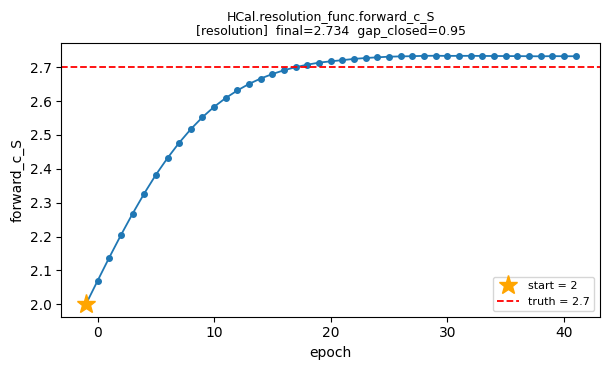

HCal.resolution_func.forward_c_S: start=2 -> final=2.73351  (truth=2.7, gap_closed=0.95, correct direction, 42 epochs, early-stopped)


In [72]:
closure("HCal.resolution_func.forward_c_S", 2.0)